# Vehicle Tracking Analysis

This notebook systematically evaluates vehicle tracking models across day and night conditions, and demonstrates real-world performance on day/night transitions.

## Workflow
1. Setup & Imports
2. Define Zones (detection areas)
3. Compare models/trackers on DAY video
4. Compare models/trackers on NIGHT video
5. Run on 10 minute day/night transition video

---
# 1. Setup & Imports
---

### 1.1 Mount Drive (Colab only)

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Not in Colab. Running locally.")

Mounted at /content/drive


### 1.2 Install & Import Libraries

In [2]:
# Auto-install if needed
%pip install -U ultralytics opencv-python-headless --quiet

import torch

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("Running on CPU")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 74.4 MB/s eta 0:00:00
GPU: Tesla T4
VRAM: 15.6 GB


### 1.3 Project Setup & Load Custom Modules

In [10]:
import importlib
import os
import sys
from pathlib import Path

sys.path.insert(0, str((Path.cwd() / "src").resolve()))
from config import PROJECT_ROOT
os.chdir(PROJECT_ROOT)

from src import GT as GT_mod
from src import evaluation, explainable_ai as xai_mod, run_video_deploy as run_video_deploy_mod, tracking_utils, day_night_detection as dnd

for module in (evaluation, tracking_utils, GT_mod, xai_mod, run_video_deploy_mod):
    importlib.reload(module)

from src.GT import CLASS_ORDER, FLOW_ORDER, load_gt_persons, load_gt_vehicles
from src.evaluation import display_model_results, plot_class_distribution_detailed, run_experiments
from src.run_video_deploy import run_video_deploy
from src.tracking_utils import display_lines_on_frame, setup_tracking_context

---
# 2. Define Zones
---

Define detection zones (gate zones) where vehicles are counted and classified.

In [11]:
GATE_ZONES = {
    "S": {"polygon": [(35, 255), (360, 255), (280, 450), (0, 450)], "dir": "S", "type": "vehicle"},
    "N": {"polygon": [(355, 155), (430, 125), (370, 250), (185, 245)], "dir": "N", "type": "vehicle"},
    "E": {"polygon": [(400, 200), (790, 200), (790, 305), (360, 325)], "dir": "E", "type": "vehicle"},
    "Gangfeltet": {"polygon": [(250, 165), (250, 200), (420, 195), (420, 175)], "dir": "Gangfeltet", "type": "person"},
}

print(f"Defined {len(GATE_ZONES)} zones: {list(GATE_ZONES.keys())}")

Defined 4 zones: ['S', 'N', 'E', 'Gangfeltet']


### 2.1 Visualize Zones on Sample Frame

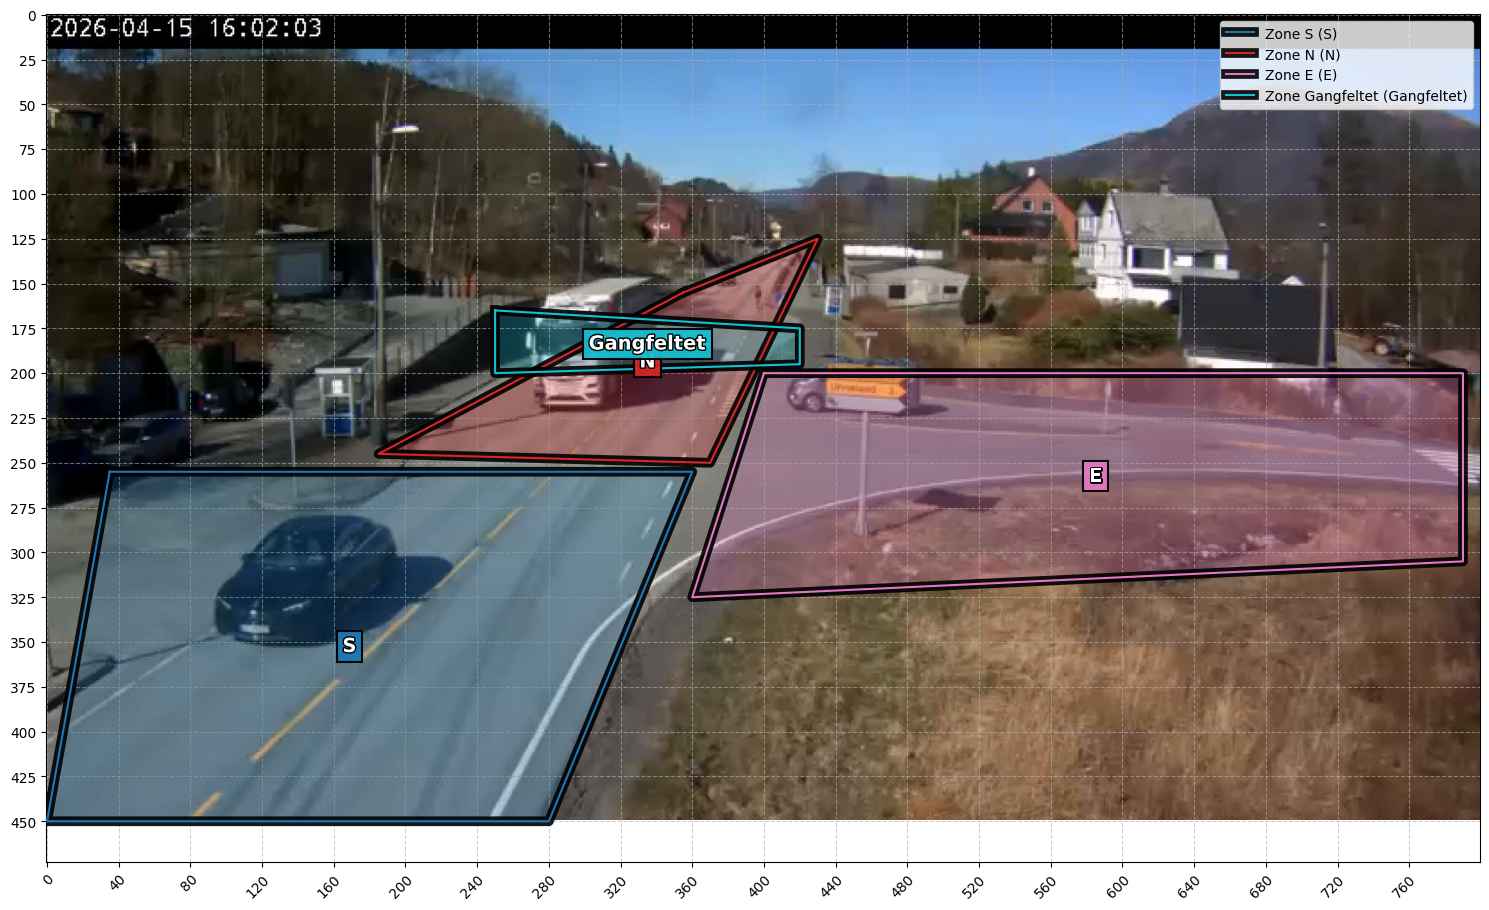

{}

In [ ]:
# Visualize zones on a sample frame
cfg_sample = setup_tracking_context(
    video_name="Fv587_Haukeland_day_diff_10min.mp4",
    drive_base=PROJECT_ROOT,
    apply_globals=False
)
display_lines_on_frame(cfg_sample["video_source"], arm_zones=GATE_ZONES)

---
# 3. Compare Models & Trackers on DAY Video
---

## 3.1 Comparing models & trackers on 15-minute daytime video

### 3.1.1 Configuration for 15-minute daytime video

In [ ]:
# 15-minute daytime video configuration
VIDEO_DAY = "Fv587_Haukeland_15min.mp4"

# Models to test
MODELS_DAY = [
    "YOLO26n_final.pt",
    "YOLO26m_final.pt",
]
# Trackers to test
TRACKERS_DAY = {
    "bytetrack": "bytetrack.yaml",
    "botsort": "botsort.yaml",
    "day_botsort": "day_botsort.yaml",
}

# Load ground truth for daytime video (vehicles)
gt_dict_day_vehicles, gt_df_day = load_gt_vehicles(VIDEO_DAY)

# Load ground truth for daytime video (persons)
gt_gangfeltet_day, gt_persons_day = load_gt_persons(VIDEO_DAY)

### 3.1.2 Run 15-minute daytime video

In [ ]:
# Run daytime experiments using the generic function
all_results_day, all_pred_tables_day, all_diff_tables_day, summary_df_day, persons_df_day = run_experiments(
    models=MODELS_DAY,
    trackers=TRACKERS_DAY,
    video_name=VIDEO_DAY,
    gt_df=gt_df_day,
    gt_persons=gt_persons_day,
    session_label="DAY",
    video_type="day",
    save_video=False,
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
    setup_tracking_context=setup_tracking_context,
    run_video_deploy=run_video_deploy,
    gate_zones=GATE_ZONES,
),

display(summary_df_day[["model", "tracker", "sum_mae", "cell_mae", "total_abs_pct_err", "elapsed_s"]])

print("\n" + "="*80)
print("DAY RESULTS SUMMARY - PERSONS")
print("="*80)
display(persons_df_day)

Running DAY video experiments with run_video_deploy...


DAY | YOLO26n_final.pt | bytetrack
Day-tracker only: bytetrack.yaml
  18000/18066 | 57.0 FPS
  Finalizing remaining tracks...
  Finalized 2 remaining tracks

Tracking Complete
Output: None
Duration: 316.9s | FPS: 57.0
Frames: 18066 | Day: 0 | Night: 0
Mode switches: 0
Detections: 41714 | Stable tracks: 352
Counted trips: 239
Fallback recovery: same_id=3, split_id=1

Complete

DAY | YOLO26n_final.pt | botsort
Day-tracker only: botsort.yaml
  18000/18066 | 33.7 FPS
  Finalizing remaining tracks...
  Finalized 2 remaining tracks

Tracking Complete
Output: None
Duration: 535.9s | FPS: 33.7
Frames: 18066 | Day: 0 | Night: 0
Mode switches: 0
Detections: 41855 | Stable tracks: 284
Counted trips: 239
Fallback recovery: same_id=1, split_id=1

Complete

DAY | YOLO26n_final.pt | day_botsort
Day-tracker only: /content/drive/MyDrive/SVV/Master_Thesis/Model/day_botsort.yaml
WARNING ⚠️ 'source' is missing. Using 'source=/usr/local/lib/python3.1

,model,tracker,sum_mae,cell_mae,total_abs_pct_err,elapsed_s
0,YOLO26m_final.pt,day_botsort,0.000000,0.047619,0.000000,545.180401
1,YOLO26m_final.pt,bytetrack,0.000000,0.142857,0.000000,378.860373
2,YOLO26m_final.pt,botsort,0.000000,0.142857,0.000000,603.060124
3,YOLO26n_final.pt,bytetrack,0.500000,0.166667,0.420168,316.936316
4,YOLO26n_final.pt,botsort,0.500000,0.214286,0.420168,535.929697
5,YOLO26n_final.pt,day_botsort,0.833333,0.309524,2.100840,480.558496



DAY RESULTS SUMMARY - PERSONS


,model,tracker,gt_persons,predicted_persons,error,pct_error
0,YOLO26n_final.pt,bytetrack,3,0,-3,100.000000
1,YOLO26n_final.pt,botsort,3,0,-3,100.000000
2,YOLO26n_final.pt,day_botsort,3,0,-3,100.000000
3,YOLO26m_final.pt,bytetrack,3,5,2,66.666667
4,YOLO26m_final.pt,botsort,3,5,2,66.666667
5,YOLO26m_final.pt,day_botsort,3,3,0,0.000000


In [ ]:
# Run daytime experiments using the generic function
all_results_day, all_pred_tables_day, all_diff_tables_day, summary_df_day, persons_df_day = run_experiments(
    models=MODELS_DAY,
    trackers=TRACKERS_DAY,
    video_name=VIDEO_DAY,
    gt_df=gt_df_day,
    gt_persons=gt_persons_day,
    session_label="DAY",
    video_type="day",
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
    setup_tracking_context=setup_tracking_context,
    run_video_deploy=run_video_deploy,
    gate_zones=GATE_ZONES,
),

print("\n" + "="*80)
print("DAY RESULTS SUMMARY - VEHICLES")
print("="*80)
display(summary_df_day[["model", "tracker", "sum_mae", "cell_mae", "total_abs_pct_err", "elapsed_s"]])

print("\n" + "="*80)
print("DAY RESULTS SUMMARY - PERSONS")
print("="*80)
display(persons_df_day)

Running DAY video experiments with run_video_deploy...


DAY | YOLO26n_final.pt | bytetrack
Day-tracker only: bytetrack.yaml
  18000/18066 | 67.6 FPS
  Finalizing remaining tracks...
  Finalized 2 remaining tracks

Tracking Complete
Output: None
Duration: 267.4s | FPS: 67.6
Frames: 18066 | Day: 0 | Night: 0
Mode switches: 0
Detections: 41714 | Stable tracks: 352
Counted trips: 239
Fallback recovery: same_id=2, split_id=1

Complete

DAY | YOLO26n_final.pt | botsort
Day-tracker only: botsort.yaml
  18000/18066 | 38.0 FPS
  Finalizing remaining tracks...
  Finalized 2 remaining tracks

Tracking Complete
Output: None
Duration: 476.0s | FPS: 38.0
Frames: 18066 | Day: 0 | Night: 0
Mode switches: 0
Detections: 41855 | Stable tracks: 284
Counted trips: 239
Fallback recovery: same_id=1, split_id=1

Complete

DAY | YOLO26n_final.pt | day_botsort
Day-tracker only: /content/drive/MyDrive/SVV/Master_Thesis/Model/day_botsort.yaml
WARNING ⚠️ 'source' is missing. Using 'source=/usr/local/lib/python3.1

,model,tracker,sum_mae,cell_mae,total_abs_pct_err,elapsed_s
0,YOLO26m_final.pt,day_botsort,0.000000,0.047619,0.000000,487.899825
1,YOLO26m_final.pt,bytetrack,0.000000,0.142857,0.000000,359.813047
2,YOLO26m_final.pt,botsort,0.000000,0.142857,0.000000,531.643617
3,YOLO26n_final.pt,bytetrack,0.500000,0.166667,0.420168,267.417501
4,YOLO26n_final.pt,botsort,0.500000,0.214286,0.420168,476.028497
5,YOLO26n_final.pt,day_botsort,0.833333,0.309524,2.100840,416.139076



DAY RESULTS SUMMARY - PERSONS


,model,tracker,gt_persons,predicted_persons,error,pct_error
0,YOLO26n_final.pt,bytetrack,3,0,-3,100.000000
1,YOLO26n_final.pt,botsort,3,0,-3,100.000000
2,YOLO26n_final.pt,day_botsort,3,0,-3,100.000000
3,YOLO26m_final.pt,bytetrack,3,5,2,66.666667
4,YOLO26m_final.pt,botsort,3,5,2,66.666667
5,YOLO26m_final.pt,day_botsort,3,3,0,0.000000


### 3.1.3 Visualizations of 15-minute daytime video

In [ ]:
# Use display_model_results for detailed analysis
display_model_results(
    gt_df=gt_df_day,
    all_pred_tables=all_pred_tables_day,
    all_diff_tables=all_diff_tables_day,
    summary_df=summary_df_day,
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
 )


=== GROUND TRUTH ===


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,134,5,2,1,0,1,0,143
N->S,71,4,4,1,1,3,0,84
E->S,1,0,0,0,0,0,0,1
E->N,1,0,0,0,0,0,0,1
S->E,4,0,0,0,0,1,0,5
N->E,4,0,0,0,0,0,0,4



  MODEL: YOLO26m_final.pt  |  TRACKER: botsort

--- PREDICTION TABLE ---


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,133,6,2,1,0,1,0,143
N->S,72,3,4,2,1,2,0,84
E->S,1,0,0,0,0,0,0,1
E->N,1,0,0,0,0,0,0,1
S->E,4,0,0,0,0,1,0,5
N->E,4,0,0,0,0,0,0,4



--- DIFF TABLE (pred - gt) ---


...


--- DIFF TABLE (pred - gt) ---


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum,Route Err %
S->N,5,-1,0,0,0,0,0,4,4.2
N->S,1,-1,-1,2,0,-1,0,0,7.1
E->S,0,0,0,0,0,0,0,0,0.0
E->N,1,0,0,0,0,0,0,1,100.0
S->E,0,0,0,0,0,0,0,0,0.0
N->E,0,0,0,0,0,0,0,0,0.0



--- CLASS ERROR (ALL ROUTES, % of GT) ---


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle
All routes,3.3,22.2,16.7,100.0,0.0,20.0,NaN



  sum_mae=0.83  |  cell_mae=0.31  |  class_rel_err=5.5%  |  route_rel_err=18.6%  |  total_pred=243  |  total_gt=238  |  total_err=5  |  total_abs_pct_err=2.1%  |  perfect_routes=3


In [ ]:
# Use display_model_results for detailed analysis
display_model_results(
    gt_df=gt_df_day,
    all_pred_tables=all_pred_tables_day,
    all_diff_tables=all_diff_tables_day,
    summary_df=summary_df_day,
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
 )


=== GROUND TRUTH ===


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,134,5,2,1,0,1,0,143
N->S,71,4,4,1,1,3,0,84
E->S,1,0,0,0,0,0,0,1
E->N,1,0,0,0,0,0,0,1
S->E,4,0,0,0,0,1,0,5
N->E,4,0,0,0,0,0,0,4



  MODEL: YOLO26m_final.pt  |  TRACKER: botsort

--- PREDICTION TABLE ---


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,133,6,2,1,0,1,0,143
N->S,72,3,4,2,1,2,0,84
E->S,1,0,0,0,0,0,0,1
E->N,1,0,0,0,0,0,0,1
S->E,4,0,0,0,0,1,0,5
N->E,4,0,0,0,0,0,0,4



--- DIFF TABLE (pred - gt) ---


...


  sum_mae=0.50  |  cell_mae=0.17  |  total_pred=239  |  total_gt=238  |  total_err=1  |  total_abs_pct_err=0.4%  |  perfect_routes=3

  MODEL: YOLO26n_final.pt  |  TRACKER: day_botsort

--- PREDICTION TABLE ---


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,139,4,2,1,0,1,0,147
N->S,72,3,3,3,1,2,0,84
E->S,1,0,0,0,0,0,0,1
E->N,2,0,0,0,0,0,0,2
S->E,4,0,0,0,0,1,0,5
N->E,4,0,0,0,0,0,0,4



--- DIFF TABLE (pred - gt) ---


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,5,-1,0,0,0,0,0,4
N->S,1,-1,-1,2,0,-1,0,0
E->S,0,0,0,0,0,0,0,0
E->N,1,0,0,0,0,0,0,1
S->E,0,0,0,0,0,0,0,0
N->E,0,0,0,0,0,0,0,0



  sum_mae=0.83  |  cell_mae=0.31  |  total_pred=243  |  total_gt=238  |  total_err=5  |  total_abs_pct_err=2.1%  |  perfect_routes=3



DAY - CLASS COMPOSITION & DISTRIBUTION


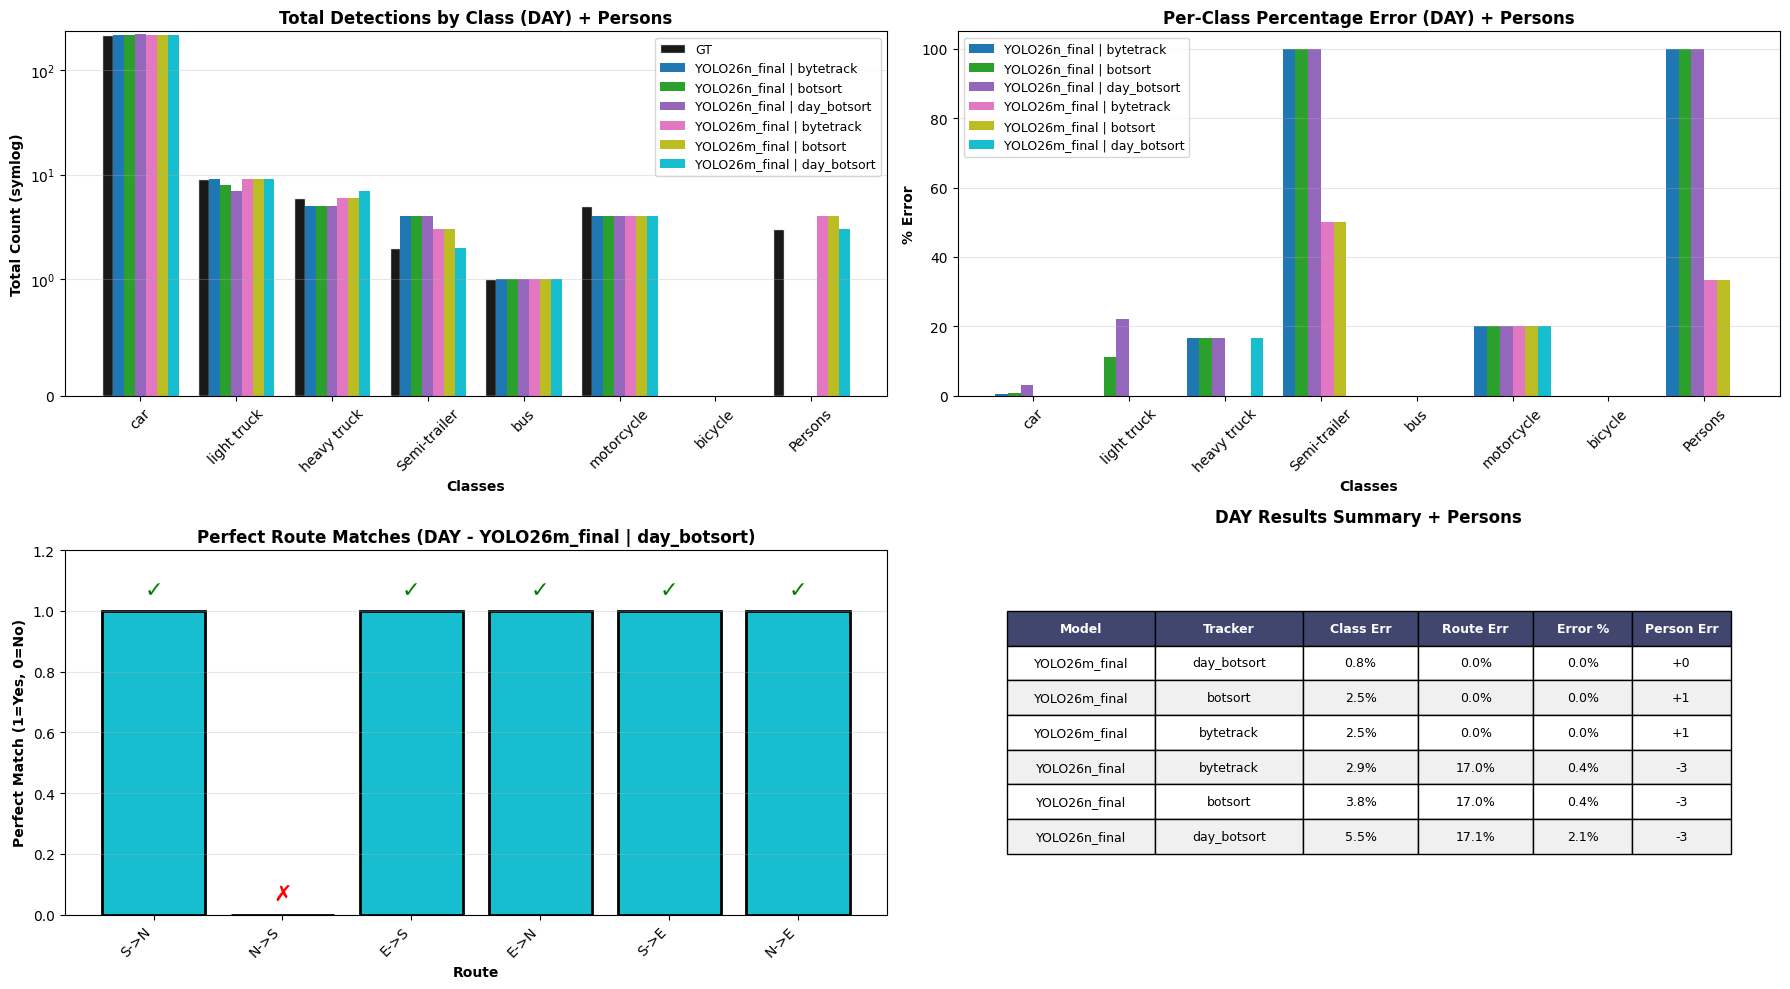


Class composition analysis complete


In [ ]:
# Plot class distribution for the 15-minute daytime video
plot_class_distribution_detailed(
    all_pred_tables=all_pred_tables_day,
    all_diff_tables=all_diff_tables_day,
    gt_df=gt_df_day,
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
    video_type="DAY",
    all_results=all_results_day,
    gt_persons=gt_persons_day,
    person_label="Persons",
    person_zone_name="Gangfeltet",
)

## 3.2 Test the best model and tracker on a 1-hour rush video

In [ ]:
# 1-hour daytime video
VIDEO_FULL = "Fv587_Haukeland_day_1h_rush.mp4"

# Best model/tracker from 15-minute daytime experiments
MODELS_1H_DAY = ["YOLO26m_final.pt"]
TRACKERS_1H_DAY = {
    "day_botsort": "day_botsort.yaml",
}

# Load ground truth for 1-hour daytime video (vehicles)
gt_dict_1h_day, gt_df_1h_day = load_gt_vehicles(VIDEO_FULL)

# Load ground truth for 1-hour daytime video (persons, Gangfeltet)
gt_gangfeltet_1h_day, gt_persons_1h_day = load_gt_persons(VIDEO_FULL)

# Run 1-hour daytime evaluation
all_results_1h_day, all_pred_tables_1h_day, all_diff_tables_1h_day, summary_df_1h_day, persons_df_1h_day = run_experiments(
    models=MODELS_1H_DAY,
    trackers=TRACKERS_1H_DAY,
    video_name=VIDEO_FULL,
    gt_df=gt_df_1h_day,
    gt_persons=gt_persons_1h_day,
    session_label="1h DAY",
    video_type="day",
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
    save_video=False,
    setup_tracking_context=setup_tracking_context,
    run_video_deploy=run_video_deploy,
    gate_zones=GATE_ZONES,
),

results_1h_day = all_results_1h_day[(MODELS_1H_DAY[0], "day_botsort")]

display(summary_df_1h_day[["model", "tracker", "sum_mae", "cell_mae", "total_abs_pct_err", "elapsed_s"]])

print("\n" + "="*80)
print("1h DAY RESULTS SUMMARY - PERSONS")
print("="*80)
display(persons_df_1h_day)

# Fallback recovery IDs
fallback = results_1h_day.get("fallback_stats", {})
same_ids = fallback.get("same_id_track_ids", [])
split_matches = fallback.get("split_id_matches", [])

print("\n" + "="*80)
print("FALLBACK RECOVERY DETAILS")
print("="*80)
print(f"same_id count: {fallback.get('added_same_id', 0)}")
print(f"split_id count: {fallback.get('added_split_id', 0)}")

print("\nSame-ID recovered track IDs:")
print(sorted(set(int(t) for t in same_ids)) if same_ids else "None")

print("\nSplit-ID recovered matches (start_id -> end_id):")
if split_matches:
    for m in split_matches:
        print(f"  {m['start_id']} -> {m['end_id']} | {m['origin']} -> {m['dest']} | score={m['score']:.2f}")
else:
    print("None")

Running 1h DAY video experiments with run_video_deploy...


1h DAY | YOLO26m_final.pt | day_botsort
Day-tracker only: /content/drive/MyDrive/SVV/Master_Thesis/Model/day_botsort.yaml
WARNING ⚠️ 'source' is missing. Using 'source=/usr/local/lib/python3.12/dist-packages/ultralytics/assets'.
  71800/71899 | 32.9 FPS
  Finalizing remaining tracks...
  Finalized 0 remaining tracks

Tracking Complete
Output: None
Duration: 2183.5s | FPS: 32.9
Frames: 71899 | Day: 0 | Night: 0
Mode switches: 0
Detections: 178747 | Stable tracks: 1281
Counted trips: 1080
Person counts by zone: {'Gangfeltet': 6}
Fallback recovery: same_id=2, split_id=19

Complete

1h DAY RESULTS SUMMARY - VEHICLES


,model,tracker,sum_mae,cell_mae,total_abs_pct_err,elapsed_s
0,YOLO26m_final.pt,day_botsort,1.166667,0.595238,0.468604,2183.507868



1h DAY RESULTS SUMMARY - PERSONS


,model,tracker,gt_persons,predicted_persons,error,pct_error
0,YOLO26m_final.pt,day_botsort,7,6,-1,14.285714



FALLBACK RECOVERY DETAILS
same_id count: 2
split_id count: 19

Same-ID recovered track IDs:
[1930, 3279]

Split-ID recovered matches (start_id -> end_id):
  155 -> 163 | N -> S | score=125.57
  396 -> 414 | E -> N | score=98.78
  475 -> 490 | N -> S | score=48.55
  610 -> 629 | N -> S | score=45.26
  987 -> 999 | N -> S | score=136.46
  1306 -> 1331 | N -> S | score=65.11
  1529 -> 1548 | N -> S | score=100.02
  1535 -> 1556 | E -> N | score=87.42
  1643 -> 1651 | S -> N | score=87.93
  1660 -> 1683 | E -> N | score=84.68
  2427 -> 2434 | N -> S | score=112.34
  2586 -> 2597 | N -> S | score=107.95
  2623 -> 2697 | N -> S | score=36.06
  2707 -> 2728 | N -> S | score=61.78
  3015 -> 3027 | N -> S | score=70.29
  3308 -> 3319 | N -> S | score=76.90
  3444 -> 3456 | N -> S | score=44.09
  4155 -> 4166 | N -> S | score=54.76
  4180 -> 4219 | N -> S | score=27.38


In [ ]:
# Display results again
display_model_results(
    gt_df=gt_df_1h_day,
    all_pred_tables=all_pred_tables_1h_day,
    all_diff_tables=all_diff_tables_1h_day,
    summary_df=summary_df_1h_day,
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
 )


=== GROUND TRUTH ===


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,523,16,14,15,3,17,1,589
N->S,354,11,11,14,2,13,2,407
E->S,18,0,0,0,0,0,0,18
E->N,16,0,0,0,0,0,1,17
S->E,18,0,0,0,0,1,4,23
N->E,10,1,0,0,2,0,0,13



  MODEL: YOLO26m_final.pt  |  TRACKER: day_botsort

--- PREDICTION TABLE ---


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,529,19,11,14,3,17,1,594
N->S,352,11,11,15,3,14,2,408
E->S,18,0,0,0,0,0,0,18
E->N,16,1,0,0,0,0,0,17
S->E,18,0,0,0,0,3,1,22
N->E,10,1,0,0,2,0,0,13



--- DIFF TABLE (pred - gt) ---


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum,Route Err %
S->N,6,3,-3,-1,0,0,0,5,2.2
N->S,-2,0,0,1,1,1,0,1,1.2
E->S,0,0,0,0,0,0,0,0,0.0
E->N,0,1,0,0,0,0,-1,0,11.8
S->E,0,0,0,0,0,2,-3,-1,21.7
N->E,0,0,0,0,0,0,0,0,0.0



--- CLASS ERROR (ALL ROUTES, % of GT) ---


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle
All routes,0.9,14.3,12.0,6.9,14.3,9.7,50.0



  sum_mae=1.17  |  cell_mae=0.60  |  class_rel_err=2.3%  |  route_rel_err=6.2%  |  total_pred=1072  |  total_gt=1067  |  total_err=5  |  total_abs_pct_err=0.5%  |  perfect_routes=2


### 3.2.3 Class distribution and perfect routes


DAY - CLASS COMPOSITION & DISTRIBUTION


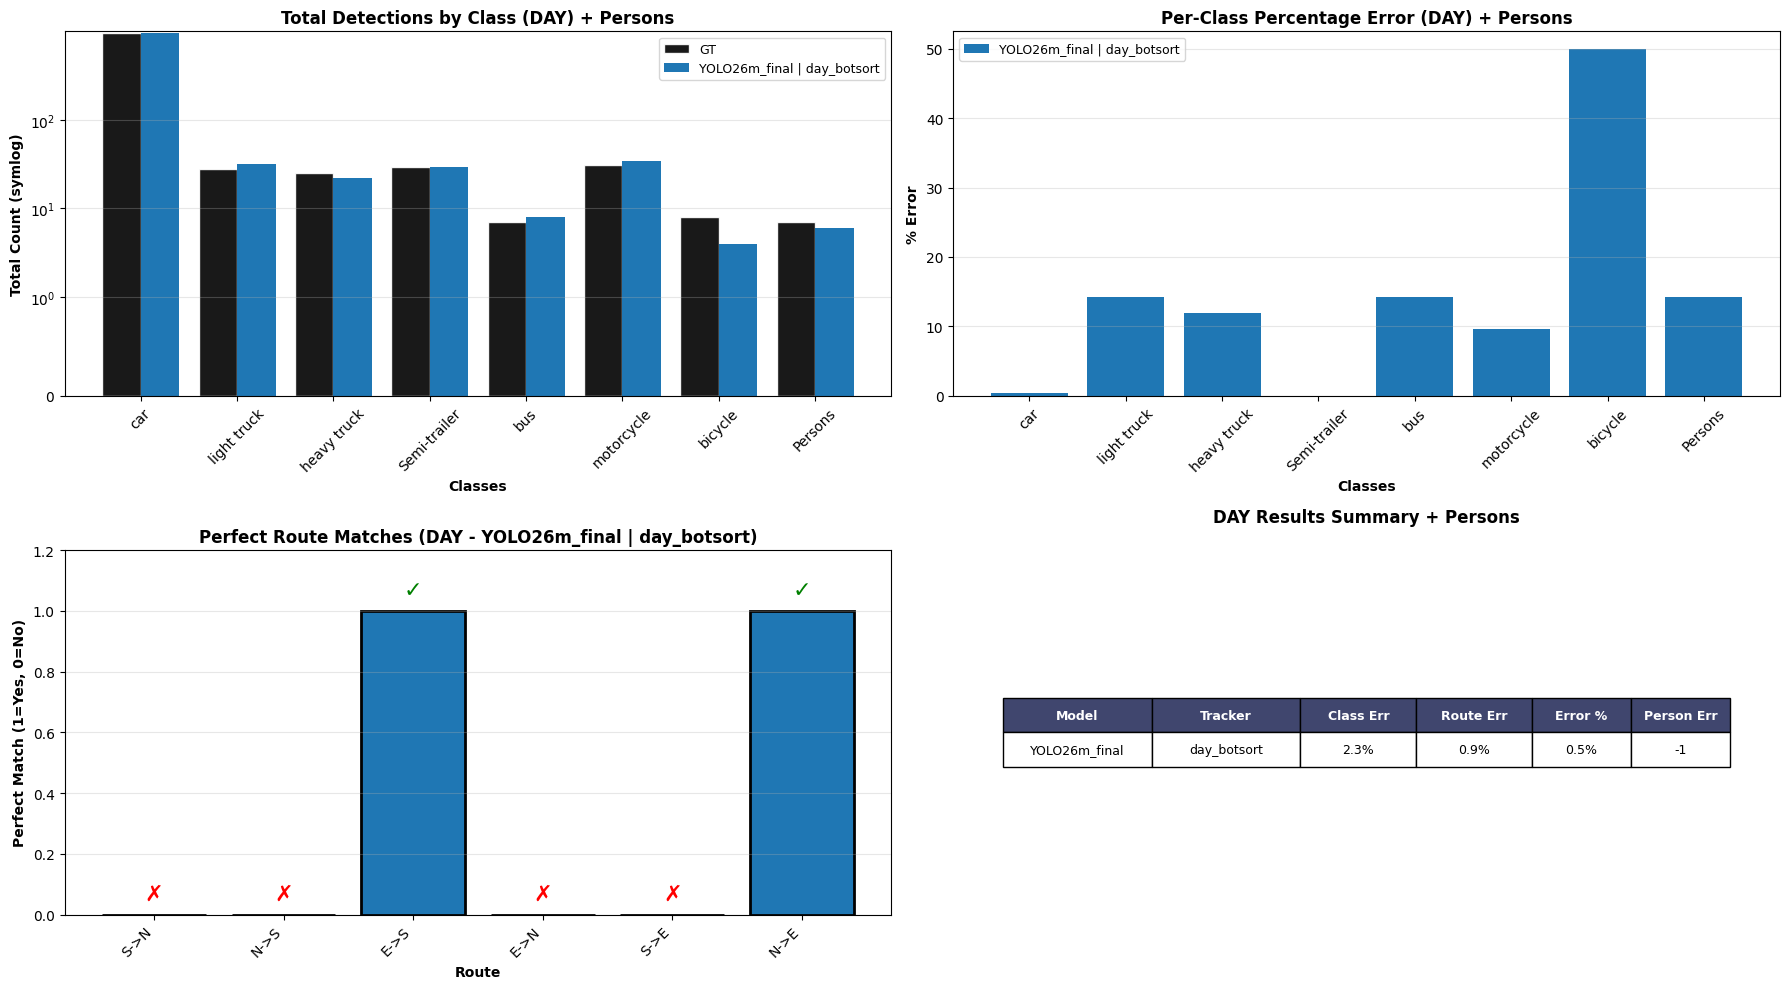


Class composition analysis complete


In [ ]:
# Plot class distribution for the 1-hour daytime video
plot_class_distribution_detailed(
    all_pred_tables=all_pred_tables_1h_day,
    all_diff_tables=all_diff_tables_1h_day,
    gt_df=gt_df_1h_day,
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
    video_type="DAY",
    all_results=all_results_1h_day,
    gt_persons=gt_persons_1h_day,
    person_label="Persons",
    person_zone_name="Gangfeltet",
)

---
# 4. Compare Models & Trackers on 1-hour night video
---

### 4.1 Night video configuration

In [ ]:
# 1-hour night video configuration
VIDEO_NIGHT = "Fv587_Haukeland_night_1h.mp4"

# Models to test
MODELS_NIGHT = [
    "YOLO26n_final.pt",
    "YOLO26m_final.pt",
]
# Trackers to test
TRACKERS_NIGHT = {
    "bytetrack": "bytetrack.yaml",
    "botsort": "botsort.yaml",
    "night_botsort_conservative": "night_botsort_conservative.yaml",
}

# Load ground truth for night video (vehicles)
gt_dict_night_vehicles, gt_df_night = load_gt_vehicles(VIDEO_NIGHT)

# Load ground truth for night video (persons, Gangfeltet)
gt_gangfeltet_night, gt_persons_night = load_gt_persons(VIDEO_NIGHT)

### 4.2 Run night experiments

In [ ]:
# Run night experiments using the generic function
all_results_night, all_pred_tables_night, all_diff_tables_night, summary_df_night, persons_df_night = run_experiments(
    models=MODELS_NIGHT,
    trackers=TRACKERS_NIGHT,
    video_name=VIDEO_NIGHT,
    gt_df=gt_df_night,
    gt_persons=gt_persons_night,
    session_label="NIGHT",
    video_type="night",
    flow_order=FLOW_ORDER,
    save_video=False,
    class_order=CLASS_ORDER,
    setup_tracking_context=setup_tracking_context,
    run_video_deploy=run_video_deploy,
    min_track_frames=2,
    gate_zones=GATE_ZONES,
),

display(summary_df_night[["model", "tracker", "sum_mae", "cell_mae", "total_abs_pct_err", "elapsed_s"]])

print("\n" + "="*80)
print("NIGHT RESULTS SUMMARY - PERSONS")
print("="*80)
display(persons_df_night)

Running NIGHT video experiments with run_video_deploy...


NIGHT | YOLO26n_final.pt | bytetrack
Night-tracker only: bytetrack.yaml
  24900/24991 | 62.2 FPS
  Finalizing remaining tracks...
  Finalized 0 remaining tracks

Tracking Complete
Output: None
Duration: 401.7s | FPS: 62.2
Frames: 24991 | Day: 0 | Night: 0
Mode switches: 0
Detections: 4538 | Stable tracks: 189
Counted trips: 129
Fallback recovery: same_id=10, split_id=2

Complete

NIGHT | YOLO26n_final.pt | botsort
Night-tracker only: botsort.yaml
  24900/24991 | 42.4 FPS
  Finalizing remaining tracks...
  Finalized 0 remaining tracks

Tracking Complete
Output: None
Duration: 589.2s | FPS: 42.4
Frames: 24991 | Day: 0 | Night: 0
Mode switches: 0
Detections: 4546 | Stable tracks: 176
Counted trips: 129
Fallback recovery: same_id=12, split_id=2

Complete

NIGHT | YOLO26n_final.pt | night_botsort_conservative
Night-tracker only: /content/drive/MyDrive/SVV/Master_Thesis/Model/night_botsort_conservative.yaml
  24900/24991 | 60.6 FPS
 

,model,tracker,sum_mae,cell_mae,total_abs_pct_err,elapsed_s
0,YOLO26m_final.pt,night_botsort_conservative,0.333333,0.285714,1.492537,532.075094
1,YOLO26m_final.pt,bytetrack,0.833333,0.309524,3.731343,559.503875
2,YOLO26m_final.pt,botsort,1.000000,0.380952,4.477612,703.717467
3,YOLO26n_final.pt,night_botsort_conservative,1.166667,0.261905,2.238806,412.563129
4,YOLO26n_final.pt,bytetrack,1.500000,0.309524,3.731343,401.705130
5,YOLO26n_final.pt,botsort,1.500000,0.309524,3.731343,589.175912



NIGHT RESULTS SUMMARY - PERSONS


,model,tracker,gt_persons,predicted_persons,error,pct_error
0,YOLO26n_final.pt,bytetrack,0,0,0,NaN
1,YOLO26n_final.pt,botsort,0,0,0,NaN
2,YOLO26n_final.pt,night_botsort_conservative,0,0,0,NaN
3,YOLO26m_final.pt,bytetrack,0,0,0,NaN
4,YOLO26m_final.pt,botsort,0,0,0,NaN
5,YOLO26m_final.pt,night_botsort_conservative,0,0,0,NaN



### 4.3 Night results visualization

In [ ]:
# Use display_model_results for detailed analysis
display_model_results(
    gt_df=gt_df_night,
    all_pred_tables=all_pred_tables_night,
    all_diff_tables=all_diff_tables_night,
    summary_df=summary_df_night,
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
 )


=== GROUND TRUTH ===


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,60,0,1,6,1,0,0,68
N->S,54,1,1,1,1,2,0,60
E->S,2,0,0,0,0,0,0,2
E->N,2,0,0,0,0,0,0,2
S->E,2,0,0,0,0,0,0,2
N->E,0,0,0,0,0,0,0,0



  MODEL: YOLO26m_final.pt  |  TRACKER: botsort

--- PREDICTION TABLE ---


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,60,0,5,2,1,0,0,68
N->S,50,1,0,2,1,0,0,54
E->S,2,0,0,0,0,0,0,2
E->N,2,0,0,0,0,0,0,2
S->E,2,0,0,0,0,0,0,2
N->E,0,0,0,0,0,0,0,0



--- DIFF TABLE (pred - gt) ---


...


--- DIFF TABLE (pred - gt) ---


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum,Route Err %
S->N,0,0,-1,1,0,0,0,0,2.9
N->S,-2,-1,-1,1,0,-2,0,-5,11.7
E->S,0,0,0,0,0,0,0,0,0.0
E->N,2,0,0,0,0,0,0,2,100.0
S->E,0,0,0,0,0,0,0,0,0.0
N->E,0,0,0,0,0,0,0,0,NaN



--- CLASS ERROR (ALL ROUTES, % of GT) ---


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle
All routes,3.3,100.0,100.0,28.6,0.0,100.0,NaN



  sum_mae=1.17  |  cell_mae=0.26  |  class_rel_err=8.2%  |  route_rel_err=22.9%  |  total_pred=131  |  total_gt=134  |  total_err=-3  |  total_abs_pct_err=2.2%  |  perfect_routes=3



NIGHT - CLASS COMPOSITION & DISTRIBUTION


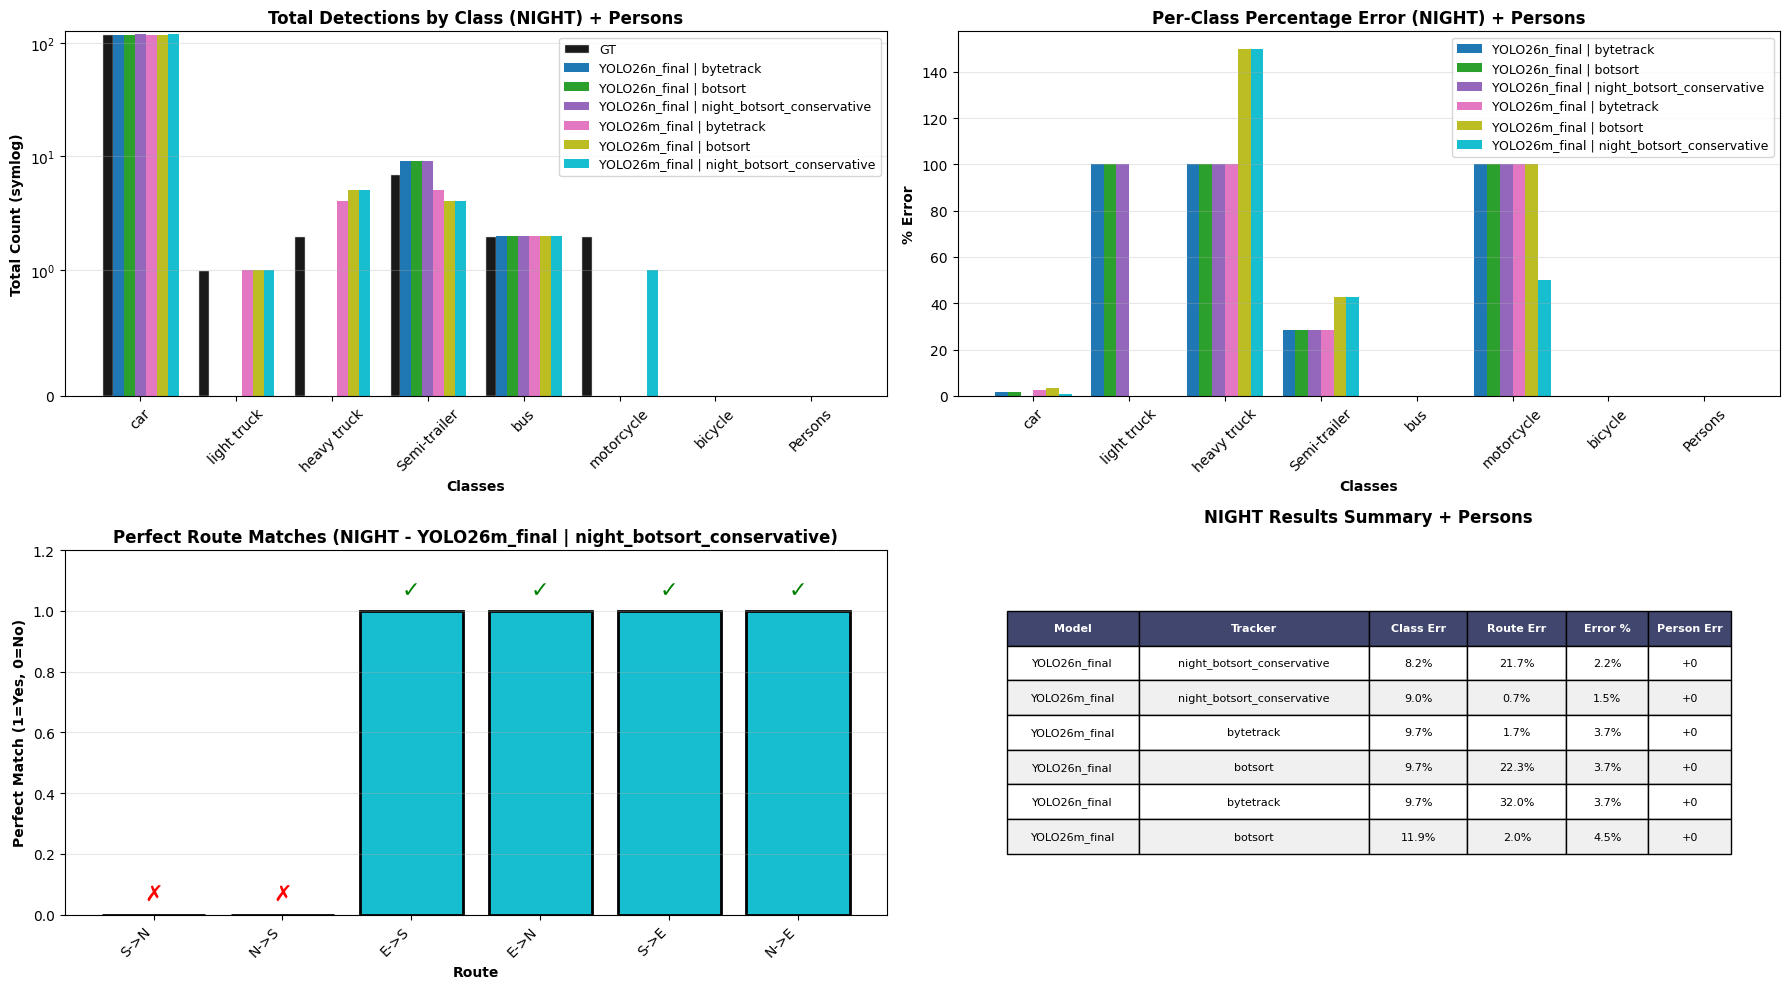


Class composition analysis complete


In [ ]:
# Plot class distribution for the night video
plot_class_distribution_detailed(
    all_pred_tables=all_pred_tables_night,
    all_diff_tables=all_diff_tables_night,
    gt_df=gt_df_night,
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
    video_type="NIGHT",
    all_results=all_results_night,
    gt_persons=gt_persons_night,
    person_label="Persons",
    person_zone_name="Gangfeltet",
)

---
# 5. Run on 10-minute day/night transition video
---

### 5.1 Configuration for transition video

In [ ]:
# 10-minute transition video configuration
VIDEO_TRANSITION = "Fv587_Haukeland_10min_transition.mp4"

# Best model/tracker setup (single best pair)
BEST_MODEL = ["YOLO26m_final.pt"]

# Convenience vars reused in the run cell
best_day_tracker_yaml = "day_botsort.yaml"
best_night_tracker_yaml = "night_botsort_conservative.yaml"

# Load ground truth once
gt_dict_transition, gt_df_transition = load_gt_vehicles(VIDEO_TRANSITION)
gt_gangfeltet_transition, gt_persons_transition = load_gt_persons(VIDEO_TRANSITION)

### 5.2 Find saturation levels in the video

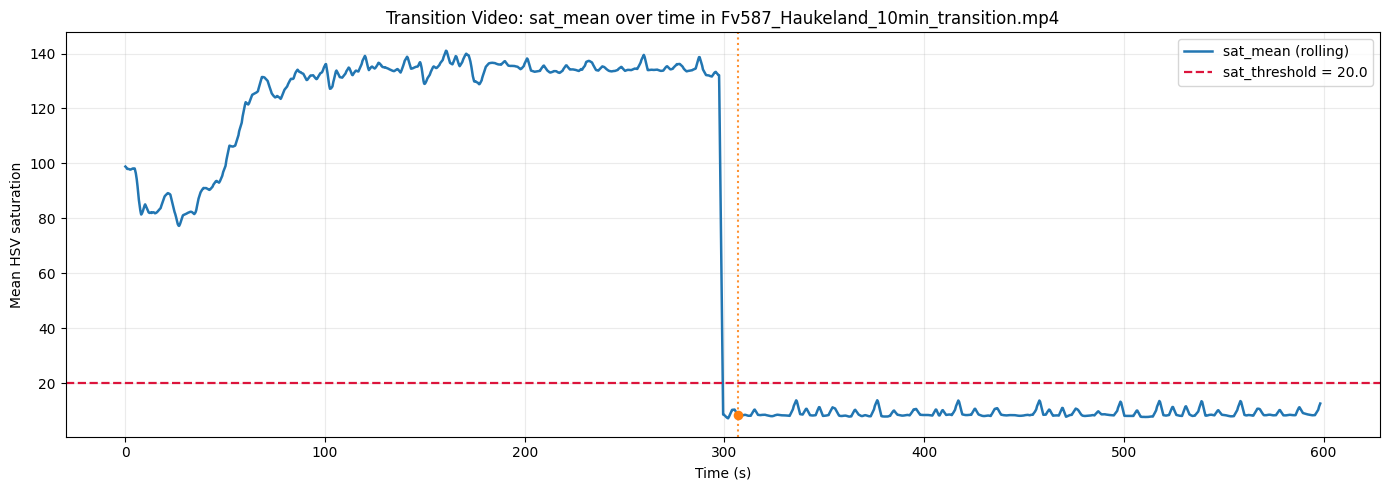

In [ ]:
# Plot sat_mean over time with the threshold and switch points
sat_analysis = dnd.plot_saturation_with_switch_points(
    video_path=str(Path(PROJECT_ROOT) / "Video" / VIDEO_TRANSITION),
    sat_threshold=20.0,
    initial_mode="day",
    title=f"Transition Video: sat_mean over time in {VIDEO_TRANSITION}",
)

### 5.3 Run transition video

In [ ]:
# Run transition experiments (reuse config from previous cell)
all_results_transition, all_pred_tables_transition, all_diff_tables_transition, summary_df_transition, persons_df_transition = run_experiments(
    models=BEST_MODEL,
    trackers={
        "transition_best": {
            "day": best_day_tracker_yaml,
            "night": best_night_tracker_yaml,
        }
    },
    video_name=VIDEO_TRANSITION,
    gt_df=gt_df_transition,
    gt_persons=gt_persons_transition,
    session_label="TRANSITION",
    video_type="transition",
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
    setup_tracking_context=setup_tracking_context,
    run_video_deploy=run_video_deploy,
    min_track_frames=2,
    gate_zones=GATE_ZONES,
),

print("\n" + "="*80)
print("TRANSITION RESULTS SUMMARY - VEHICLES")
print("="*80)
display(summary_df_transition[["model", "tracker", "sum_mae", "cell_mae", "total_abs_pct_err", "elapsed_s"]])

print("\n" + "="*80)
print("TRANSITION RESULTS SUMMARY - PERSONS")
print("="*80)
display(persons_df_transition)

Running TRANSITION video experiments with run_video_deploy...


TRANSITION | YOLO26m_final.pt | transition_best
Dual-tracker mode: /content/drive/MyDrive/SVV/Master_Thesis/Model/day_botsort.yaml (day) ↔ /content/drive/MyDrive/SVV/Master_Thesis/Model/night_botsort_conservative.yaml (night)
WARNING ⚠️ 'source' is missing. Using 'source=/usr/local/lib/python3.12/dist-packages/ultralytics/assets'.
  6000/11793 | 36.4 FPS
 TRACKER SWITCH at frame 6045: NIGHT (sat=8.3, lum=85.3)
  11700/11793 | 37.4 FPS
  Finalizing remaining tracks...
  Finalized 0 remaining tracks

Tracking Complete
Output: /content/drive/MyDrive/SVV/Master_Thesis/Model/runs/instance/Fv587_Haukeland_10min_transition_204158.mp4
Duration: 315.4s | FPS: 37.4
Frames: 11793 | Day: 6044 | Night: 5749
Mode switches: 1
Detections: 5627 | Stable tracks: 65
Counted trips: 30
Fallback recovery: same_id=1, split_id=0

Complete

TRANSITION RESULTS SUMMARY - VEHICLES

TRANSITION RESULTS SUMMARY - VEHICLES


,model,tracker,sum_mae,cell_mae,total_abs_pct_err,elapsed_s
0,YOLO26m_final.pt,transition_best,0.0,0.0,0.0,315.355778



TRANSITION RESULTS SUMMARY - PERSONS


,model,tracker,gt_persons,predicted_persons,error,pct_error
0,YOLO26m_final.pt,transition_best,0,0,0,NaN


### 5.4 Ground-truth matrix comparison

In [ ]:
# Use display_model_results for detailed analysis
display_model_results(
    gt_df=gt_df_transition,
    all_pred_tables=all_pred_tables_transition,
    all_diff_tables=all_diff_tables_transition,
    summary_df=summary_df_transition,
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
 )


=== GROUND TRUTH ===


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,16,0,0,0,0,0,0,16
N->S,10,0,0,0,1,0,1,12
E->S,0,0,0,0,0,0,0,0
E->N,1,0,0,0,0,0,0,1
S->E,1,0,0,0,0,0,0,1
N->E,0,0,0,0,0,0,0,0



  MODEL: YOLO26m_final.pt  |  TRACKER: transition_best

--- PREDICTION TABLE ---


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,16,0,0,0,0,0,0,16
N->S,10,0,0,0,1,0,1,12
E->S,0,0,0,0,0,0,0,0
E->N,1,0,0,0,0,0,0,1
S->E,1,0,0,0,0,0,0,1
N->E,0,0,0,0,0,0,0,0



--- DIFF TABLE (pred - gt) ---


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum,Route Err %
S->N,0,0,0,0,0,0,0,0,0.0
N->S,0,0,0,0,0,0,0,0,0.0
E->S,0,0,0,0,0,0,0,0,NaN
E->N,0,0,0,0,0,0,0,0,0.0
S->E,0,0,0,0,0,0,0,0,0.0
N->E,0,0,0,0,0,0,0,0,NaN



--- CLASS ERROR (ALL ROUTES, % of GT) ---


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle
All routes,0.0,NaN,NaN,NaN,0.0,NaN,0.0



  sum_mae=0.00  |  cell_mae=0.00  |  class_rel_err=0.0%  |  route_rel_err=0.0%  |  total_pred=30  |  total_gt=30  |  total_err=0  |  total_abs_pct_err=0.0%  |  perfect_routes=6


### 5.5 Class composition


TRANSITION - CLASS COMPOSITION & DISTRIBUTION


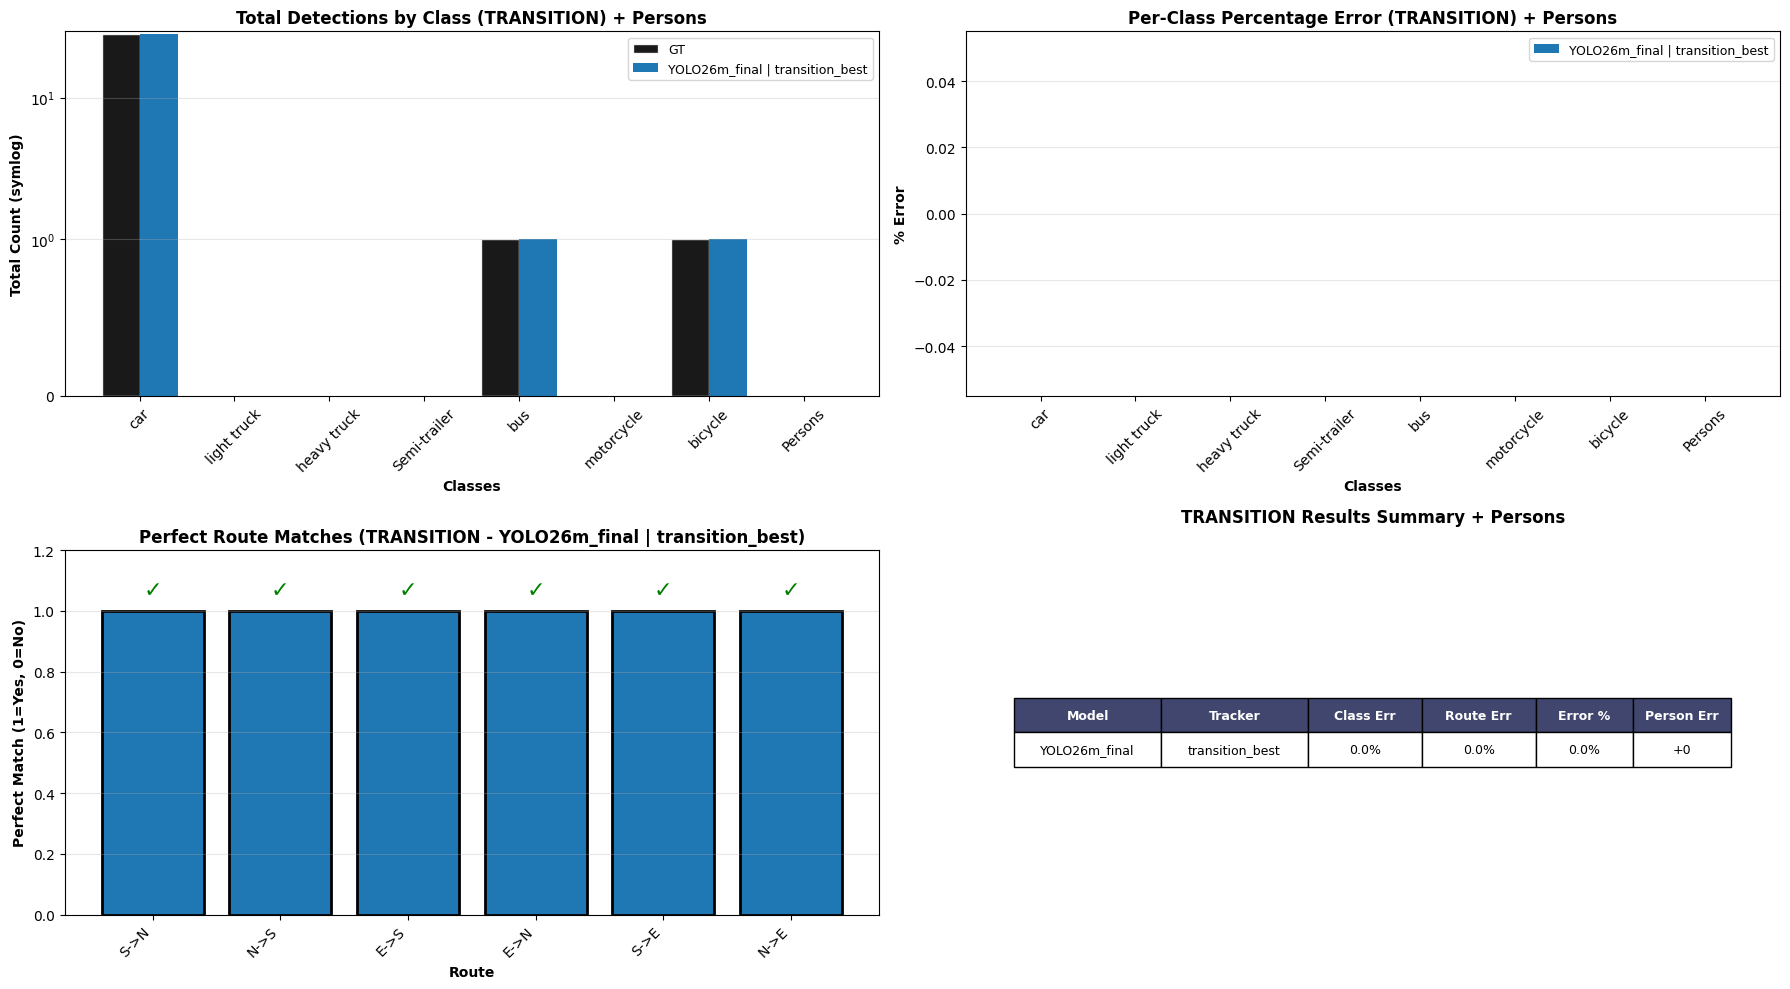


Class composition analysis complete


In [ ]:
# Plot class distribution for the transition video
plot_class_distribution_detailed(
    all_pred_tables=all_pred_tables_transition,
    all_diff_tables=all_diff_tables_transition,
    gt_df=gt_df_transition,
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
    video_type="TRANSITION",
    all_results=all_results_transition,
    gt_persons=gt_persons_transition,
    person_label="Persons",
    person_zone_name="Gangfeltet",
)

In [58]:
from datetime import datetime
from pathlib import Path
import pickle

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = Path(PROJECT_ROOT) / "results_exports" / timestamp
save_dir.mkdir(parents=True, exist_ok=True)

def save_run(label, all_results, all_pred_tables, all_diff_tables, summary_df, persons_df, gt_df=None, gt_persons=None):
    run_dir = save_dir / label
    run_dir.mkdir(parents=True, exist_ok=True)

    summary_df.to_csv(run_dir / "summary.csv", index=False)
    persons_df.to_csv(run_dir / "persons.csv", index=False)

    with open(run_dir / "pred_tables.pkl", "wb") as f:
        pickle.dump(all_pred_tables, f)
    with open(run_dir / "diff_tables.pkl", "wb") as f:
        pickle.dump(all_diff_tables, f)
    with open(run_dir / "raw_results.pkl", "wb") as f:
        pickle.dump(all_results, f)

    if gt_df is not None:
        gt_df.to_csv(run_dir / "gt_df.csv")
    if gt_persons is not None:
        (run_dir / "gt_persons.txt").write_text(str(gt_persons))

    print(f"Saved {label} to {run_dir}")

save_run(
    "15min_day",
    all_results_day,
    all_pred_tables_day,
    all_diff_tables_day,
    summary_df_day,
    persons_df_day,
    gt_df=gt_df_day,
    gt_persons=gt_persons_day,
 )

save_run(
    "1h_day",
    all_results_1h_day,
    all_pred_tables_1h_day,
    all_diff_tables_1h_day,
    summary_df_1h_day,
    persons_df_1h_day,
    gt_df=gt_df_1h_day,
    gt_persons=gt_persons_1h_day,
 )

save_run(
    "1h_night",
    all_results_night,
    all_pred_tables_night,
    all_diff_tables_night,
    summary_df_night,
    persons_df_night,
    gt_df=gt_df_night,
    gt_persons=gt_persons_night,
 )

save_run(
    "10min_transition",
    all_results_transition,
    all_pred_tables_transition,
    all_diff_tables_transition,
    summary_df_transition,
    persons_df_transition,
    gt_df=gt_df_transition,
    gt_persons=gt_persons_transition,
 )

print(f"\nAll results saved under: {save_dir}")

Saved 15min_day to /content/drive/MyDrive/SVV/Master_Thesis/Model/results_exports/20260428_204843/15min_day
Saved 1h_day to /content/drive/MyDrive/SVV/Master_Thesis/Model/results_exports/20260428_204843/1h_day
Saved 1h_night to /content/drive/MyDrive/SVV/Master_Thesis/Model/results_exports/20260428_204843/1h_night
Saved 10min_transition to /content/drive/MyDrive/SVV/Master_Thesis/Model/results_exports/20260428_204843/10min_transition

All results saved under: /content/drive/MyDrive/SVV/Master_Thesis/Model/results_exports/20260428_204843
